In [1]:
print("""
CREDIT DEFAULT TIMING PREDICTION (Multiclass Classification)
================================================================

PROBLEM STATEMENT
Traditional credit risk models only predict IF a customer will default.
This project goes further - predicting WHEN a default is likely to happen.

Target classes:
- Class 0: No Default
- Class 1: Default in 1-6 months
- Class 2: Default in 7-12 months
- Class 3: Default in 13-18 months

DATASET
- 450K+ customer records
- 188 financial behavior features
- Highly imbalanced classes (74% no-default)

APPROACH
1. Exploratory Data Analysis (8 visualizations)
2. Feature preprocessing + handling missing values
3. Model comparison: Logistic Regression, XGBoost, LightGBM
4. Best model: XGBoost - Weighted AUC (OvR): 0.9418
5. Explainability with SHAP (global feature importance + individual predictions)

BUSINESS IMPACT
By predicting WHEN a customer is likely to default, banks can:
- Prioritize collections teams based on urgency
- Apply early intervention for 1-6 month risk customers
- Reduce overall default losses through proactive risk management

KEY SKILLS DEMONSTRATED
- Multiclass classification with imbalanced data
- Model evaluation (AUC, confusion matrix, per-class metrics)
- Explainable AI (SHAP waterfall + summary plots)
- Business-oriented insights, not just metrics
================================================================
""")


CREDIT DEFAULT TIMING PREDICTION (Multiclass Classification)

PROBLEM STATEMENT
Traditional credit risk models only predict IF a customer will default.
This project goes further - predicting WHEN a default is likely to happen.

Target classes:
- Class 0: No Default
- Class 1: Default in 1-6 months
- Class 2: Default in 7-12 months
- Class 3: Default in 13-18 months

DATASET
- 450K+ customer records
- 188 financial behavior features
- Highly imbalanced classes (74% no-default)

APPROACH
1. Exploratory Data Analysis (8 visualizations)
2. Feature preprocessing + handling missing values
3. Model comparison: Logistic Regression, XGBoost, LightGBM
4. Best model: XGBoost - Weighted AUC (OvR): 0.9418
5. Explainability with SHAP (global feature importance + individual predictions)

BUSINESS IMPACT
By predicting WHEN a customer is likely to default, banks can:
- Prioritize collections teams based on urgency
- Apply early intervention for 1-6 month risk customers
- Reduce overall default losses 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install shap -q

import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb

print(" All libraries ready!")

 All libraries ready!


In [3]:
base_path = '/kaggle/input/datasets/arpan129/default-time-prediction-multiclass-amex'

X_raw = pd.read_csv(f'{base_path}/train_allx.csv')
y_raw = pd.read_csv(f'{base_path}/train_y.csv')
val_raw = pd.read_csv(f'{base_path}/val_allx.csv')

print(f"Train features shape : {X_raw.shape}")
print(f"Train labels shape   : {y_raw.shape}")
print(f"Val features shape   : {val_raw.shape}")
print(f"\nLabel columns: {y_raw.columns.tolist()}")
print(f"\nFirst few rows of labels:\n{y_raw.head()}")
print(f"\nFeature columns sample: {X_raw.columns[:10].tolist()}")

Train features shape : (458913, 189)
Train labels shape   : (458913, 1)
Val features shape   : (467966, 189)

Label columns: ['Default_Flag']

First few rows of labels:
   Default_Flag
0             0
1             0
2             0
3             0
4             0

Feature columns sample: ['ID', 'B_37', 'S_24', 'S_4', 'S_14', 'B_25', 'D_38', 'B_30', 'D_138', 'P_2']


In [4]:
# Check target distribution
print("Target column: 'Default_Flag'")
print(f"\nClass distribution:")
print(y_raw['Default_Flag'].value_counts().sort_index())
print(f"\nClass %:")
print((y_raw['Default_Flag'].value_counts(normalize=True).sort_index() * 100).round(2))
print(f"\nNumber of unique classes: {y_raw['Default_Flag'].nunique()}")

Target column: 'Default_Flag'

Class distribution:
Default_Flag
0    340085
1     34501
2     46424
3     37903
Name: count, dtype: int64

Class %:
Default_Flag
0    74.11
1     7.52
2    10.12
3     8.26
Name: proportion, dtype: float64

Number of unique classes: 4


In [5]:
# Merge features and target
df = X_raw.copy()
df['target'] = y_raw['Default_Flag'].values

print(f"Final shape: {df.shape}")
print(f"Classes: {sorted(df['target'].unique())}")

class_labels = ['0: No Default', '1: 1-6 Months', '2: 7-12 Months', '3: 13-18 Months']
class_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

Final shape: (458913, 190)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


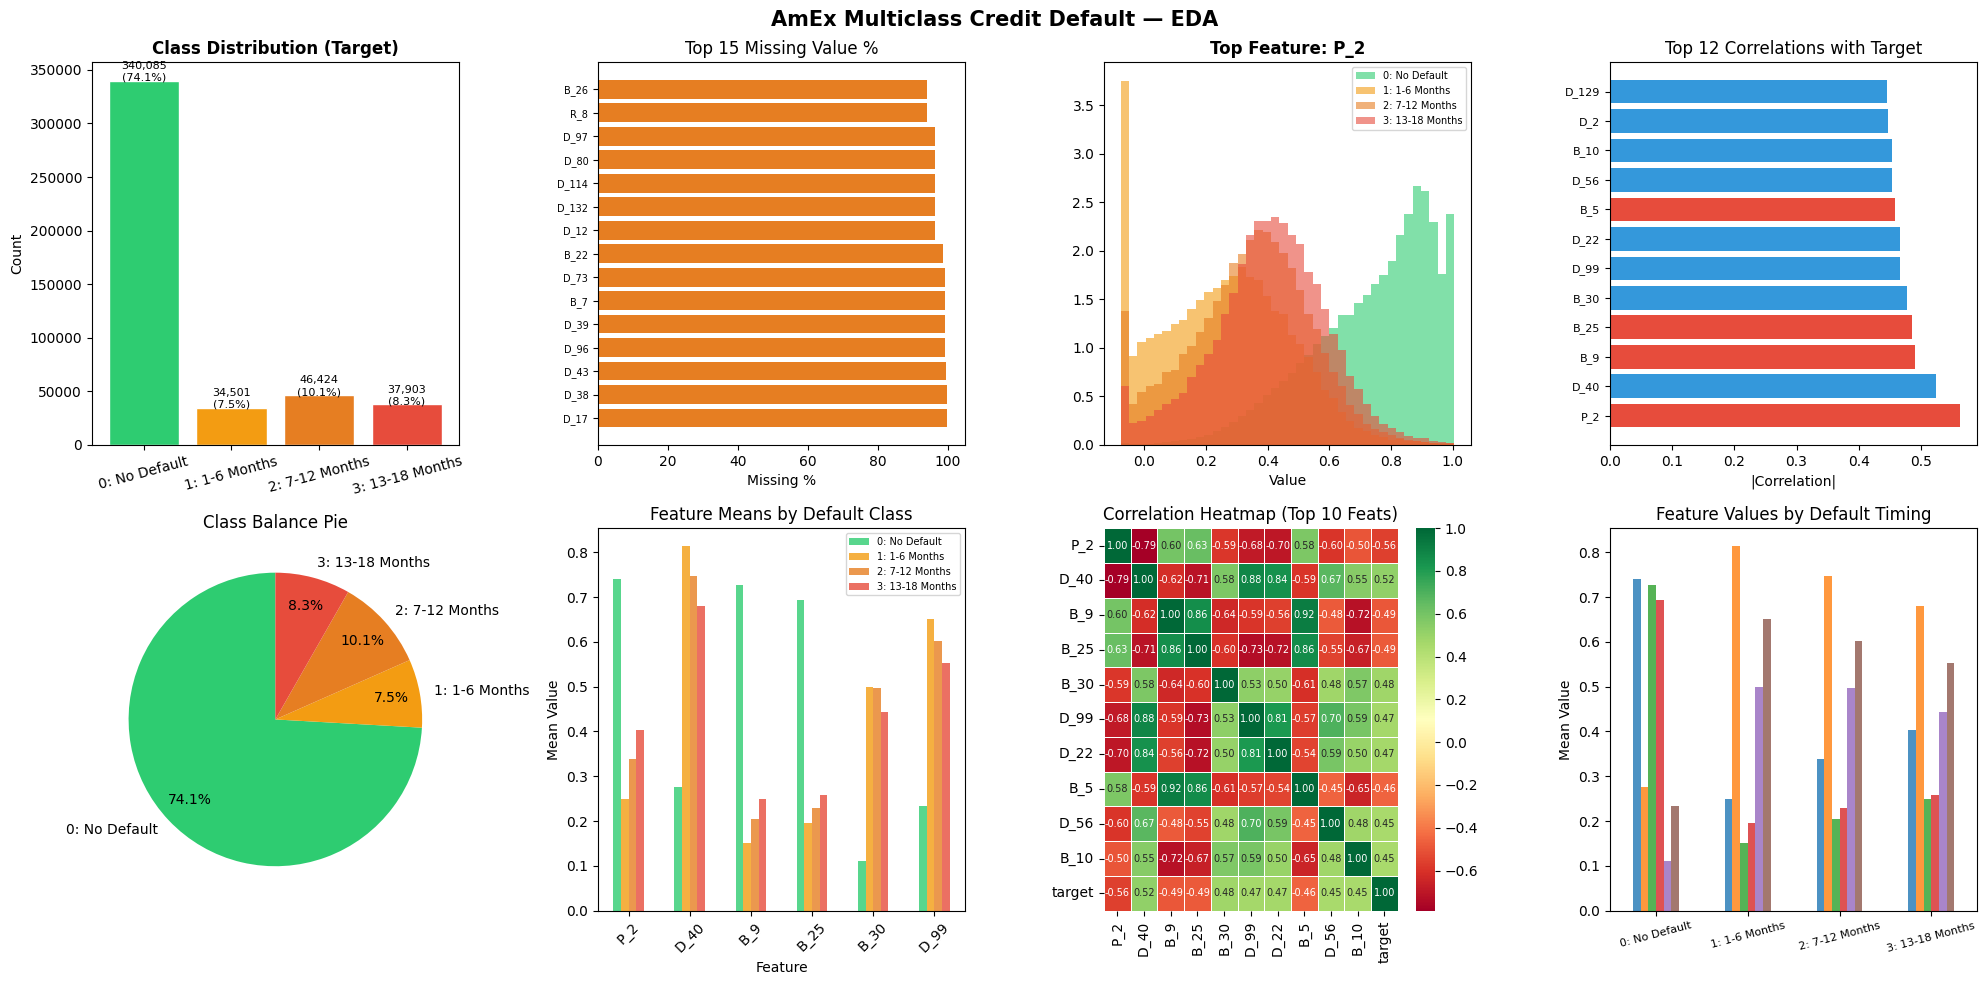

EDA complete!


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('AmEx Multiclass Credit Default — EDA', fontsize=15, fontweight='bold')

# 1. Class distribution
ax = axes[0,0]
counts = df['target'].value_counts().sort_index()
bars = ax.bar(class_labels, counts.values, color=class_colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=8)
ax.set_title('Class Distribution (Target)', fontweight='bold')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=15)

# 2. Missing values
ax = axes[0,1]
miss = (df.drop(['target','ID'],axis=1).isnull().mean()*100).sort_values(ascending=False).head(15)
ax.barh(range(len(miss)), miss.values, color='#e67e22')
ax.set_yticks(range(len(miss)))
ax.set_yticklabels([c[:22] for c in miss.index], fontsize=7)
ax.set_title('Top 15 Missing Value %'); ax.set_xlabel('Missing %')

# 3. Top feature distribution by class
ax = axes[0,2]
num_cols = df.select_dtypes(include='number').columns.drop(['target','ID'])
corr = df[num_cols].corrwith(df['target']).abs()
best_feat = corr.idxmax()
q01, q99 = df[best_feat].quantile([0.01, 0.99])
for i, c in enumerate(class_colors):
    subset = df[df['target']==i][best_feat].clip(q01, q99).dropna()
    ax.hist(subset, bins=40, alpha=0.6, color=c, label=class_labels[i], density=True)
ax.set_title(f'Top Feature: {best_feat[:20]}', fontweight='bold')
ax.legend(fontsize=7); ax.set_xlabel('Value')

# 4. Top 12 correlations with target
ax = axes[0,3]
corr_all = corr.nlargest(12)
bar_colors = ['#e74c3c' if df[f].corr(df['target']) < 0 
              else '#3498db' for f in corr_all.index]
ax.barh(range(len(corr_all)), corr_all.values, color=bar_colors)
ax.set_yticks(range(len(corr_all)))
ax.set_yticklabels([c[:22] for c in corr_all.index], fontsize=8)
ax.set_title('Top 12 Correlations with Target'); ax.set_xlabel('|Correlation|')

# 5. Class balance pie
ax = axes[1,0]
ax.pie(counts.values, labels=class_labels, colors=class_colors,
       autopct='%1.1f%%', startangle=90, pctdistance=0.8)
ax.set_title('Class Balance Pie')

# 6. Feature means by class
ax = axes[1,1]
feat_sample = corr.nlargest(6).index.tolist()
means_by_class = df.groupby('target')[feat_sample].mean()
means_by_class.T.plot(kind='bar', ax=ax, color=class_colors, alpha=0.8)
ax.set_title('Feature Means by Default Class')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean Value')
ax.tick_params(axis='x', rotation=45)
ax.legend(class_labels, fontsize=7)

# 7. Correlation heatmap (top 10)
ax = axes[1,2]
top10 = corr.nlargest(10).index.tolist()
corr_matrix = df[top10 + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, annot_kws={'size':7}, linewidths=0.5)
ax.set_title('Correlation Heatmap (Top 10 Feats)')

# 8. Feature progression by default timing
ax = axes[1,3]
class_means = df.groupby('target')[top10[:6]].mean()
class_means.plot(kind='bar', ax=ax, alpha=0.8, legend=False)
ax.set_xticklabels(class_labels, rotation=15, fontsize=8)
ax.set_title('Feature Values by Default Timing')
ax.set_ylabel('Mean Value'); ax.set_xlabel('')

plt.tight_layout()
plt.savefig('eda_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA complete!")

In [7]:
y = df['target'].values
X = df.drop(['target', 'ID'], axis=1)

# Encode object columns if any
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Fill missing with median
X.fillna(X.median(), inplace=True)

print(f"Feature matrix: {X.shape}")
print(f"Classes: {np.unique(y)} | Counts: {np.bincount(y.astype(int))}")

Feature matrix: (458913, 188)
Classes: [0 1 2 3] | Counts: [340085  34501  46424  37903]


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Class distribution (train): {np.bincount(y_train.astype(int))}")
print(f"Class distribution (val)  : {np.bincount(y_val.astype(int))}")

Train: (367130, 188) | Val: (91783, 188)
Class distribution (train): [272068  27601  37139  30322]
Class distribution (val)  : [68017  6900  9285  7581]


In [9]:
num_classes = len(np.unique(y))
results = {}

def multiclass_auc(y_true, y_proba):
    return roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')

# Use a sample for fast training (50k rows is enough for good AUC)
sample_idx = np.random.RandomState(42).choice(len(X_train), 50000, replace=False)
X_tr_s = X_train.iloc[sample_idx]
y_tr_s = y_train[sample_idx]

# 1. Logistic Regression baseline
print("1/3 Logistic Regression (baseline)...")
lr = LogisticRegression(max_iter=200, class_weight='balanced',
                         multi_class='multinomial', C=0.1, random_state=42)
lr.fit(X_tr_s, y_tr_s)
lr_p = lr.predict_proba(X_val)
lr_pred = lr.predict(X_val)
results['Logistic Regression'] = {'AUC': multiclass_auc(y_val, lr_p), 'proba': lr_p, 'pred': lr_pred}
print(f"   Weighted AUC: {results['Logistic Regression']['AUC']:.4f}")

# 2. XGBoost — early_stopping_rounds in constructor (new API)
print("2/3 XGBoost...")
xgb_m = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.7,
    objective='multi:softprob', num_class=num_classes,
    eval_metric='mlogloss', verbosity=0, random_state=42, n_jobs=-1,
    early_stopping_rounds=20
)
xgb_m.fit(X_tr_s, y_tr_s, eval_set=[(X_val, y_val)], verbose=False)
xgb_p = xgb_m.predict_proba(X_val)
results['XGBoost'] = {'AUC': multiclass_auc(y_val, xgb_p), 'proba': xgb_p, 'pred': xgb_m.predict(X_val)}
print(f"   Weighted AUC: {results['XGBoost']['AUC']:.4f}")

# 3. LightGBM
print("3/3 LightGBM...")
lgbm_m = lgb.LGBMClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    num_leaves=63, subsample=0.8, colsample_bytree=0.7,
    objective='multiclass', num_class=num_classes,
    class_weight='balanced', verbose=-1, random_state=42, n_jobs=-1
)
lgbm_m.fit(X_tr_s, y_tr_s, eval_set=[(X_val, y_val)],
           callbacks=[lgb.early_stopping(20, verbose=False)])
lgbm_p = lgbm_m.predict_proba(X_val)
results['LightGBM'] = {'AUC': multiclass_auc(y_val, lgbm_p), 'proba': lgbm_p, 'pred': lgbm_m.predict(X_val)}
print(f"   Weighted AUC: {results['LightGBM']['AUC']:.4f}")

print("\n" + "="*45)
print(f"{'Model':<22} {'Weighted AUC':>12}")
print("="*45)
for name, s in sorted(results.items(), key=lambda x: x[1]['AUC'], reverse=True):
    print(f"{name:<22} {s['AUC']:>12.4f}")
print("="*45)
best_model_name = max(results, key=lambda x: results[x]['AUC'])
print(f" Best: {best_model_name}")

1/3 Logistic Regression (baseline)...
   Weighted AUC: 0.9367
2/3 XGBoost...
   Weighted AUC: 0.9418
3/3 LightGBM...
   Weighted AUC: 0.9374

Model                  Weighted AUC
XGBoost                      0.9418
LightGBM                     0.9374
Logistic Regression          0.9367
 Best: XGBoost


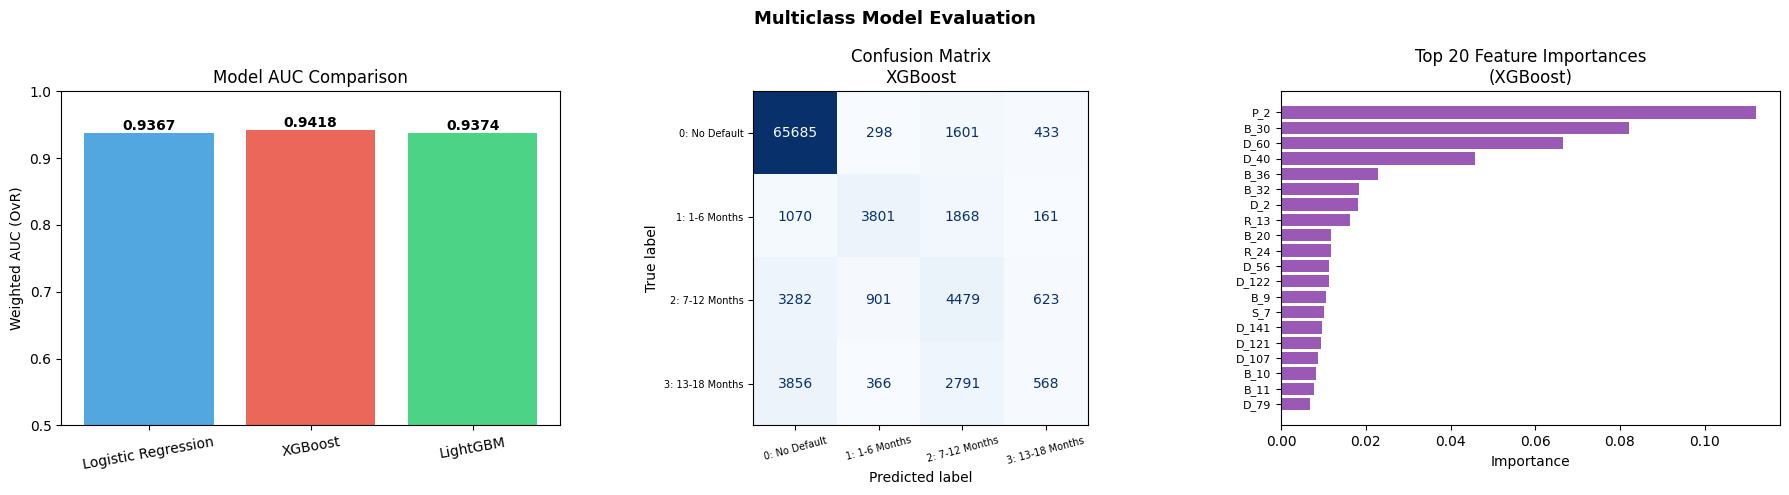

 Evaluation charts saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multiclass Model Evaluation', fontsize=13, fontweight='bold')

# 1. AUC comparison
ax = axes[0]
names = list(results.keys())
aucs = [results[n]['AUC'] for n in names]
bars = ax.bar(names, aucs, color=['#3498db','#e74c3c','#2ecc71'], alpha=0.85)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('Weighted AUC (OvR)')
ax.set_title('Model AUC Comparison')
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=10)

# 2. Confusion matrix — best model
ax = axes[1]
best = max(results, key=lambda x: results[x]['AUC'])
cm = confusion_matrix(y_val, results[best]['pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix\n{best}')
ax.set_xticklabels(class_labels, rotation=15, fontsize=7)
ax.set_yticklabels(class_labels, fontsize=7)

# 3. Feature importance — XGBoost (best model)
ax = axes[2]
fi = pd.Series(xgb_m.feature_importances_, index=X_train.columns).nlargest(20).sort_values()
ax.barh(range(len(fi)), fi.values, color='#9b59b6')
ax.set_yticks(range(len(fi)))
ax.set_yticklabels([f[:25] for f in fi.index], fontsize=8)
ax.set_title('Top 20 Feature Importances\n(XGBoost)')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('evaluation_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Evaluation charts saved!")

In [11]:
print("="*65)
print(f"DETAILED REPORT — {best_model_name}")
print("="*65)
print(classification_report(
    y_val, results[best_model_name]['pred'],
    target_names=class_labels,
    digits=4
))

print("Per-class AUC (One-vs-Rest):")
best_proba = results[best_model_name]['proba']
for i, label in enumerate(class_labels):
    y_bin = (y_val == i).astype(int)
    auc = roc_auc_score(y_bin, best_proba[:, i])
    print(f"  {label}: AUC = {auc:.4f}")

DETAILED REPORT — XGBoost
                 precision    recall  f1-score   support

  0: No Default     0.8889    0.9657    0.9257     68017
  1: 1-6 Months     0.7083    0.5509    0.6198      6900
 2: 7-12 Months     0.4171    0.4824    0.4474      9285
3: 13-18 Months     0.3182    0.0749    0.1213      7581

       accuracy                         0.8121     91783
      macro avg     0.5831    0.5185    0.5285     91783
   weighted avg     0.7805    0.8121    0.7879     91783

Per-class AUC (One-vs-Rest):
  0: No Default: AUC = 0.9567
  1: 1-6 Months: AUC = 0.9487
  2: 7-12 Months: AUC = 0.8932
  3: 13-18 Months: AUC = 0.8622


Computing SHAP values (takes ~1-2 min)...
SHAP output type: <class 'numpy.ndarray'>
SHAP array shape: (300, 188, 4)


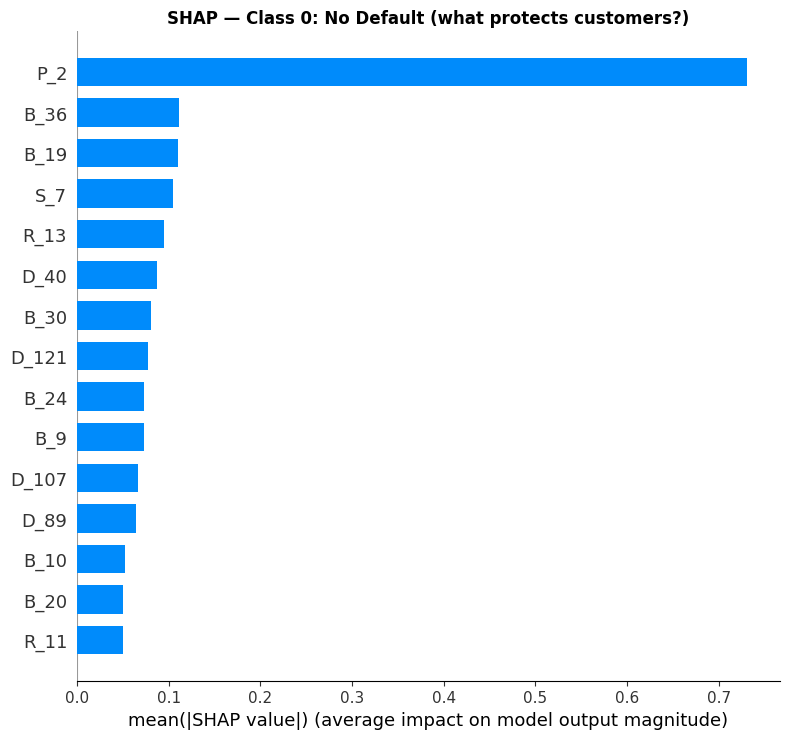

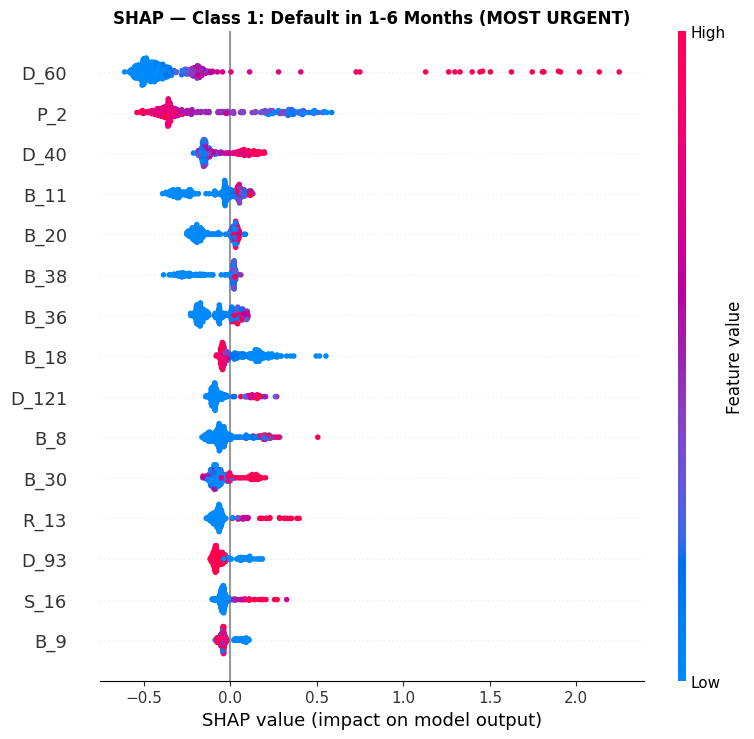

 SHAP plots saved!


In [12]:
print("Computing SHAP values (takes ~1-2 min)...")
X_shap = X_val.sample(300, random_state=42)

explainer = shap.TreeExplainer(xgb_m)
sv = explainer.shap_values(X_shap)

print(f"SHAP output type: {type(sv)}")
if isinstance(sv, list):
    print(f"Number of classes: {len(sv)}")
else:
    print(f"SHAP array shape: {sv.shape}")

# Handle both old (list) and new (3D array) SHAP output formats
if isinstance(sv, list):
    sv_class0 = sv[0]
    sv_class1 = sv[1]
else:
    sv_class0 = sv[:, :, 0]
    sv_class1 = sv[:, :, 1]

# Class 0 (No Default) — what protects customers?
plt.figure(figsize=(10,7))
shap.summary_plot(sv_class0, X_shap, max_display=15, show=False, plot_type='bar')
plt.title('SHAP — Class 0: No Default (what protects customers?)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_class0.png', dpi=150, bbox_inches='tight')
plt.show()

# Class 1 (Default in 1-6 months) — most urgent
plt.figure(figsize=(10,7))
shap.summary_plot(sv_class1, X_shap, max_display=15, show=False)
plt.title('SHAP — Class 1: Default in 1-6 Months (MOST URGENT)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_class1.png', dpi=150, bbox_inches='tight')
plt.show()

print(" SHAP plots saved!")

CUSTOMER RISK PROFILE
Predicted class : 1 (1: 1-6 Months)
Actual class    : 1 (1: 1-6 Months)

Probability per class:
  0: No Default:   0.6%  
  1: 1-6 Months:  91.6%  ███████████████████████████
  2: 7-12 Months:   5.6%  █
  3: 13-18 Months:   2.3%  


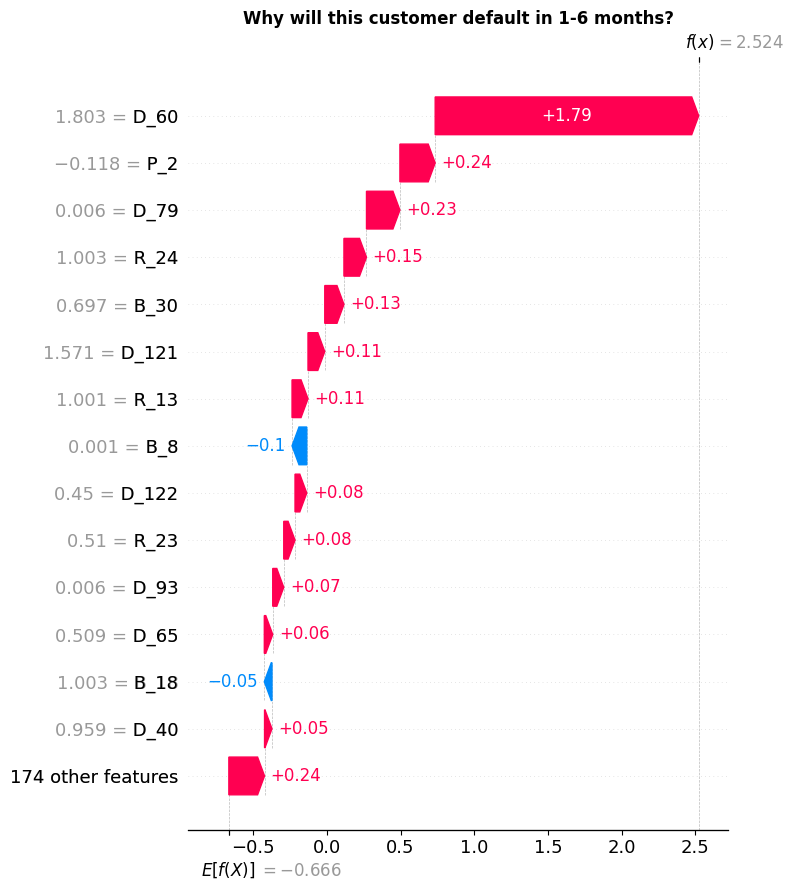

In [13]:
# Find a customer correctly predicted as Class 1 (imminent default, 1-6 months)
best_proba = results[best_model_name]['proba']
high_risk_idx = np.where((results[best_model_name]['pred'] == 1) & (y_val == 1))[0]

if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
else:
    idx = np.where(y_val == 1)[0][0]

applicant = X_val.iloc[[idx]]
probs = xgb_m.predict_proba(applicant)[0]

print("="*60)
print("CUSTOMER RISK PROFILE")
print("="*60)
print(f"Predicted class : {xgb_m.predict(applicant)[0]} ({class_labels[xgb_m.predict(applicant)[0]]})")
print(f"Actual class    : {int(y_val[idx])} ({class_labels[int(y_val[idx])]})")
print("\nProbability per class:")
for i, (label, p) in enumerate(zip(class_labels, probs)):
    bar = '█' * int(p*30)
    print(f"  {label}: {p*100:5.1f}%  {bar}")

# SHAP waterfall for Class 1 (imminent default)
app_sv = explainer.shap_values(applicant)

if isinstance(app_sv, list):
    sv_for_class1 = app_sv[1][0]
else:
    sv_for_class1 = app_sv[0, :, 1]

ev = explainer.expected_value
ev_class1 = ev[1] if isinstance(ev, (list, np.ndarray)) and len(np.atleast_1d(ev)) > 1 else ev

exp = shap.Explanation(
    values=sv_for_class1,
    base_values=ev_class1,
    data=applicant.values[0],
    feature_names=list(X_val.columns)
)
plt.figure(figsize=(10,6))
shap.waterfall_plot(exp, max_display=15, show=False)
plt.title('Why will this customer default in 1-6 months?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("="*65)
print("BUSINESS INSIGHTS — What AmEx should do")
print("="*65)

fi = pd.Series(xgb_m.feature_importances_, index=X_train.columns)

print("\n 1.) Top 5 Most Important Features:")
for f, v in fi.nlargest(5).items():
    print(f"   {f}: {v:.4f}")

# Risk distribution
pred_all = results[best_model_name]['pred']
pred_df = pd.DataFrame({'Predicted': pred_all, 'Actual': y_val})
print("\n 2.) Predicted Risk Distribution:")
pred_counts = pred_df['Predicted'].value_counts().sort_index()
for cls, cnt in pred_counts.items():
    pct = cnt/len(pred_df)*100
    print(f"   {class_labels[cls]}: {cnt:,} customers ({pct:.1f}%)")

print("\n 3.) Model Accuracy per Class:")
for i, label in enumerate(class_labels):
    mask = y_val == i
    if mask.sum() > 0:
        acc = (pred_all[mask] == i).mean() * 100
        print(f"   {label}: {acc:.1f}% correctly identified")

print(f"\n 4.) Final Scores:")
for name, s in sorted(results.items(), key=lambda x: x[1]['AUC'], reverse=True):
    print(f"   {name}: Weighted AUC = {s['AUC']:.4f}")

# Predict on val_raw (the actual unlabeled test set provided)
val_X = val_raw.drop('ID', axis=1)
for col in val_X.select_dtypes(include='object').columns:
    val_X[col] = LabelEncoder().fit_transform(val_X[col].astype(str))
val_X.fillna(X_train.median(), inplace=True)
val_X = val_X.reindex(columns=X_train.columns, fill_value=0)

val_preds = xgb_m.predict(val_X)
val_proba = xgb_m.predict_proba(val_X)

sub = pd.DataFrame({
    'ID': val_raw['ID'],
    'predicted_class': val_preds,
    'prob_no_default':      val_proba[:, 0],
    'prob_default_1_6mo':   val_proba[:, 1],
    'prob_default_7_12mo':  val_proba[:, 2],
    'prob_default_13_18mo': val_proba[:, 3]
})
sub.to_csv('submission.csv', index=False)
print(f"\n submission.csv saved — {len(sub):,} rows")
sub.head()

BUSINESS INSIGHTS — What AmEx should do

 1.) Top 5 Most Important Features:
   P_2: 0.1122
   B_30: 0.0822
   D_60: 0.0666
   D_40: 0.0459
   B_36: 0.0228

 2.) Predicted Risk Distribution:
   0: No Default: 73,893 customers (80.5%)
   1: 1-6 Months: 5,366 customers (5.8%)
   2: 7-12 Months: 10,739 customers (11.7%)
   3: 13-18 Months: 1,785 customers (1.9%)

 3.) Model Accuracy per Class:
   0: No Default: 96.6% correctly identified
   1: 1-6 Months: 55.1% correctly identified
   2: 7-12 Months: 48.2% correctly identified
   3: 13-18 Months: 7.5% correctly identified

 4.) Final Scores:
   XGBoost: Weighted AUC = 0.9418
   LightGBM: Weighted AUC = 0.9374
   Logistic Regression: Weighted AUC = 0.9367

 submission.csv saved — 467,966 rows


,ID,predicted_class,prob_no_default,prob_default_1_6mo,prob_default_7_12mo,prob_default_13_18mo
0,3337446730,0,0.996735,0.000771,0.001054,0.001439
1,7888784125,0,0.611722,0.042781,0.182022,0.163476
2,9871378905,2,0.045224,0.165437,0.519928,0.269412
3,8891869609,0,0.682183,0.068894,0.167837,0.081086
4,2006443827,0,0.575236,0.069354,0.172539,0.182871


In [15]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║   AMEX MULTICLASS DEFAULT TIME PREDICTION — COMPLETE         ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset  : Default Time Prediction Multiclass AmEx          ║
║  Target   : 0=Safe  1=Default 1-6mo  2=7-12mo  3=13-18mo     ║
║  Models   : Logistic Regression, XGBoost, LightGBM           ║
║  Best     : {best_model_name} (Weighted AUC: {results[best_model_name]['AUC']:.4f})              ║
║  Extra    : SHAP per class — global + individual             ║
╠══════════════════════════════════════════════════════════════╣
║  FILES:                                                      ║
║  → eda_multiclass.png        8 EDA charts                    ║
║  → evaluation_multiclass.png AUC + confusion + feat imp      ║
║  → shap_class0.png           No-default drivers              ║
║  → shap_class1.png           Imminent default drivers        ║
║  → shap_waterfall.png        Individual explanation          ║
║  → submission.csv            Final predictions               ║
╠══════════════════════════════════════════════════════════════╣
║  LINKEDIN POST IDEA:                                         ║
║  "Built a multiclass credit default TIMING predictor on      ║
║   real AmEx data (450K+ customers, 188 features).            ║
║   Predicts not just IF a customer defaults — but WHEN        ║
║   (1-6mo / 7-12mo / 13-18mo). XGBoost + SHAP for full        ║
║   explainability. Weighted AUC: 0.94"                        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║   AMEX MULTICLASS DEFAULT TIME PREDICTION — COMPLETE         ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset  : Default Time Prediction Multiclass AmEx          ║
║  Target   : 0=Safe  1=Default 1-6mo  2=7-12mo  3=13-18mo     ║
║  Models   : Logistic Regression, XGBoost, LightGBM           ║
║  Best     : XGBoost (Weighted AUC: 0.9418)              ║
║  Extra    : SHAP per class — global + individual             ║
╠══════════════════════════════════════════════════════════════╣
║  FILES:                                                      ║
║  → eda_multiclass.png        8 EDA charts                    ║
║  → evaluation_multiclass.png AUC + confusion + feat imp      ║
║  → shap_class0.png           No-default drivers              ║
║  → shap_class1.png           Imminent default drivers        ║
║  → shap_waterfall.png        Individual explanation          ║
║  → submission.csv          